# Credit Card Fraud Detection and Risk Analysis Business Problem:
# How can banks identify fraudulent transactions while minimizing false positives?

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Question 1: Load the dataset and inspect the first few rows.

In [7]:
df = pd.read_csv(r"C:\Users\c5i\Downloads\transactions.csv")

df.head()

,transaction_id,amount,merchant_category,hour_of_day,account_age_days,distance_from_home_km,is_fraud
0,1,61.15,Utilities,21,1263,9.4,0
1,2,38.86,Dining,17,1217,4.3,0
2,3,90.70,Online Retail,17,2621,22.3,0
3,4,67.49,Entertainment,4,599,10.7,0
4,5,29.42,ATM Withdrawal,2,2491,3.0,0


# Question: What is the shape of the dataset?

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50000
Columns: 7


# Question: Are there any missing values?

In [9]:
df.isnull().sum()

transaction_id           0
amount                   0
merchant_category        0
hour_of_day              0
account_age_days         0
distance_from_home_km    0
is_fraud                 0
dtype: int64

# Question: What is the fraud percentage?

In [10]:
fraud_rate = df["is_fraud"].mean()*100
print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 1.64%


# Fraud Distribution

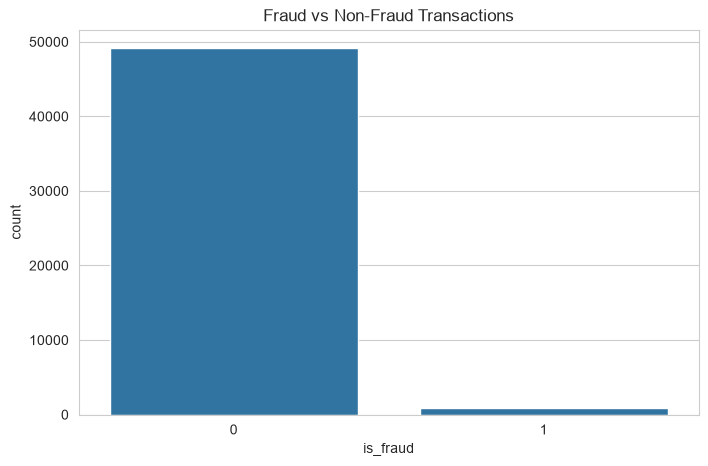

In [11]:
sns.countplot(
    x="is_fraud",
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

# Question: Which merchant categories have the highest fraud?

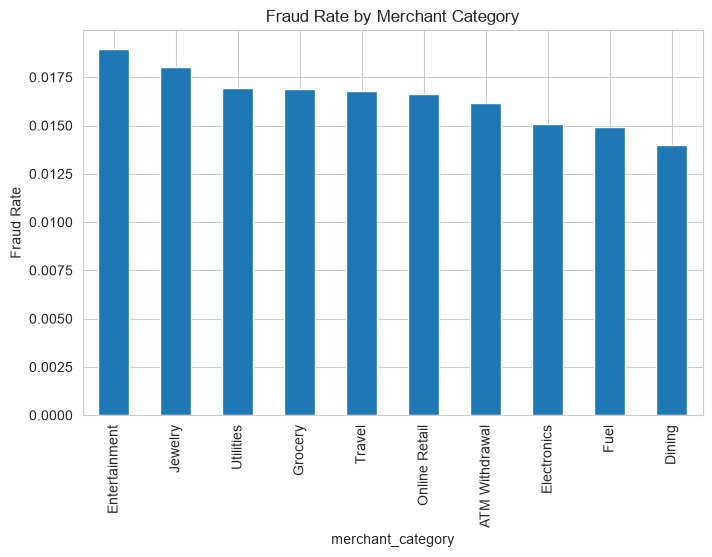

In [15]:
fraud_cat = (
    df.groupby("merchant_category")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
)

fraud_cat.plot(kind="bar")
plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.show()

# Question: Do fraudulent transactions happen at certain times?

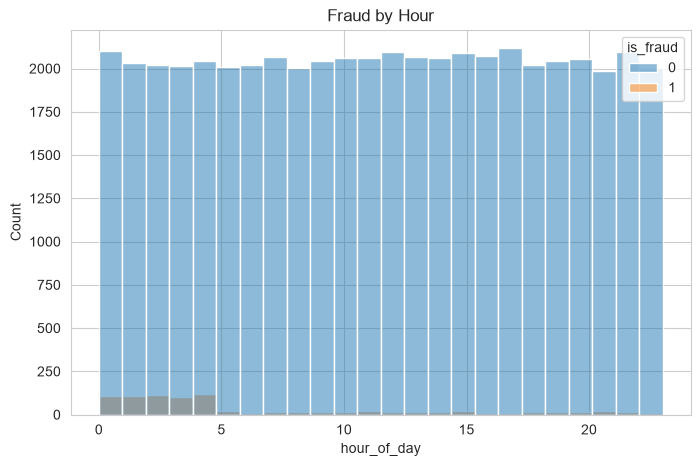

In [16]:
sns.histplot(
    data=df,
    x="hour_of_day",
    hue="is_fraud",
    bins=24
)

plt.title("Fraud by Hour")
plt.show()

# Question:Are fraudulent transactions farther from home?

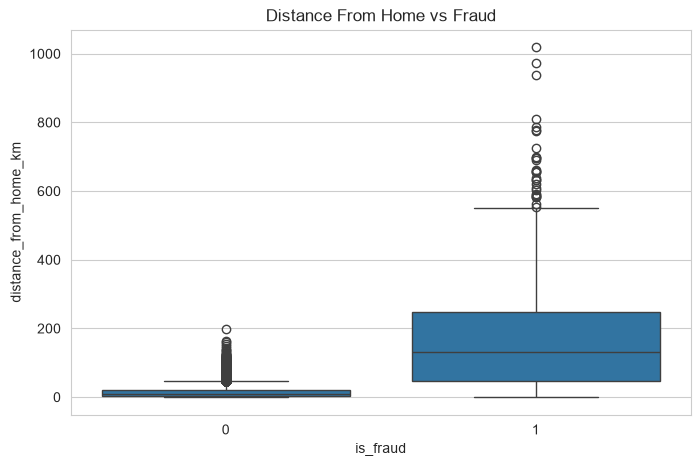

In [17]:
sns.boxplot(
    x="is_fraud",
    y="distance_from_home_km",
    data=df
)

plt.title("Distance From Home vs Fraud")
plt.show()

# Correlation Heatmap

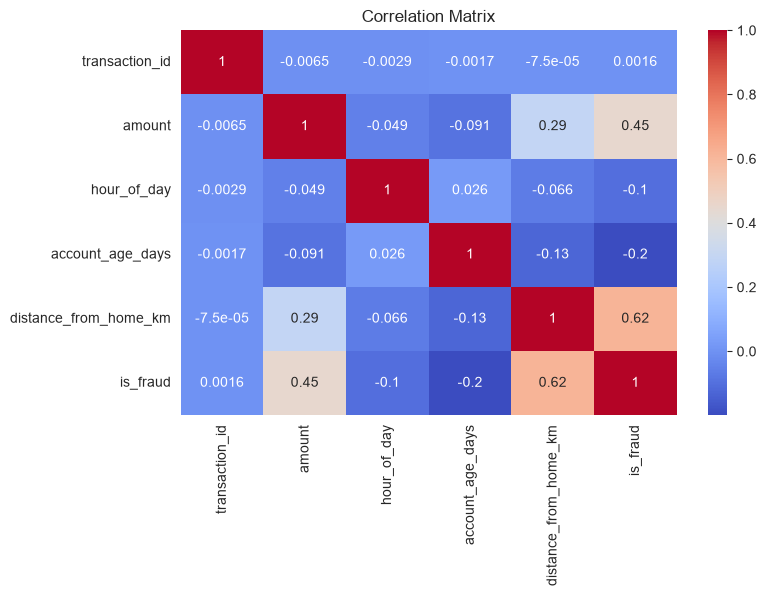

In [18]:
numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Prepare Data

In [22]:
X = df.drop(
    ["is_fraud","transaction_id"],
    axis=1
)

X = pd.get_dummies(
    X,
    drop_first=True
)

y = df["is_fraud"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression Model

In [25]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [26]:
pred = model.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9836
           1       0.94      0.83      0.88       164

    accuracy                           1.00     10000
   macro avg       0.97      0.91      0.94     10000
weighted avg       1.00      1.00      1.00     10000



# Confusion Matrix

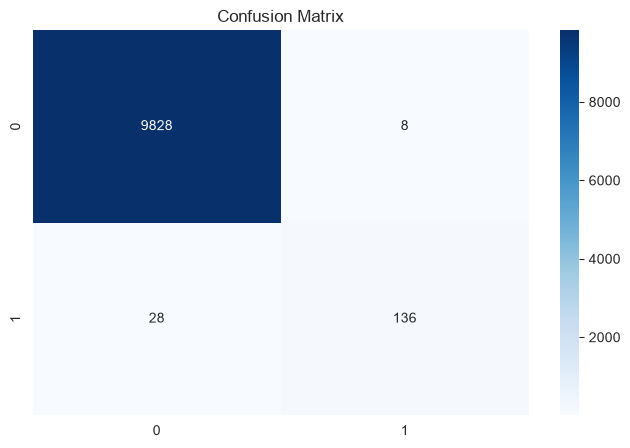

In [27]:
cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Business Recommendations
# 1.Monitor late-night transactions.
# 2.Flag high-distance transactions.
# 3.Add additional verification for new accounts.
# 4.Increase monitoring for high-risk merchant categories.
# 5.Adjust fraud threshold according to business needs.
